# Recent Equilibrium Families Inside SILVA

This notebook derives and executes four mechanisms as SILVA specializations:

1. an input-injected Fourier equilibrium for steady fields;
2. a physics-guided graph equilibrium for convection-diffusion systems;
3. a conditioned residual flow whose stationary point is a SILVA fixed point;
4. an empirical-measure equilibrium solved by particle descent.

The implementations share one umbrella equation,

$$
\begin{aligned}
z^\star
&=\Phi\!\left(
S_\theta(x)+H_\theta(z^\star)\right. \\
&\qquad\left.
+L_\theta(z^\star)+G_\theta(z^\star)\right. \\
&\qquad\left.
+B_{\mathcal F,\theta}(z^\star,x)
\right),
\end{aligned}
$$

but differ in state space, transition, and numerical path. Each section checks
the defining behavior on a small deterministic problem before the mechanisms
are connected into one heterogeneous SILVA pipeline.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [43](https://jseluis.github.io/silva-networks/paper/references/#ref-43), [44](https://jseluis.github.io/silva-networks/paper/references/#ref-44), [45](https://jseluis.github.io/silva-networks/paper/references/#ref-45), [46](https://jseluis.github.io/silva-networks/paper/references/#ref-46), [47](https://jseluis.github.io/silva-networks/paper/references/#ref-47), [48](https://jseluis.github.io/silva-networks/paper/references/#ref-48), [49](https://jseluis.github.io/silva-networks/paper/references/#ref-49), [50](https://jseluis.github.io/silva-networks/paper/references/#ref-50). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_HOSTED_RUNTIME = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_HOSTED_RUNTIME and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import math
import torch
import matplotlib.pyplot as plt
from torch import nn

from silva_networks import (
    SILVAFNODEQ,
    SILVAFNODEQBlock,
    SILVADistributionalDEQ,
    SILVADistributionalTransition,
    SILVAHomotopyEquilibrium,
    SILVAPhysicsGuidedGraphDEQ,
    SolverConfig,
    available_silva_families,
    distributional_discrepancy,
    graph_convection_diffusion,
    silva_equilibrium_model,
)

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(164)

## 1. What Changes and What Stays Fixed

For every family, SILVA still requires a state-preserving transition
$T_\theta:\mathcal Z\times\mathcal X\to\mathcal Z$. The state space changes:

| SILVA family | State | Preserved contract | Numerical path |
|---|---|---|---|
| Fourier equilibrium | field $V\in\mathbb R^{B\times C\times H\times W}$ | same grid and channels | fixed-point solver |
| physics graph equilibrium | node field $Z\in\mathbb R^{N\times D}$ | same nodes and width | fixed-point solver |
| homotopy equilibrium | vector $z\in\mathbb R^{B\times D}$ | same batch and width | Euler or RK4 residual flow |
| distributional equilibrium | particles $Z\in\mathbb R^{B\times M\times D}$ | same valid particle slots | Wasserstein-style descent |

Task error, equilibrium residual, physical residual, and distributional
discrepancy are different quantities. The examples report the diagnostic that
belongs to each mechanism.

## 2. Input-Injected Fourier Equilibrium

Let $a:\Omega\to\mathbb R^{C_a}$ be a forcing or coefficient field. SILVA
lifts it to $g=P_\phi(a)$ and repeatedly applies a tied Fourier block:

$$
\begin{aligned}
v_{j+1}
&=g+\sigma\!\left(
W_jv_j\right. \\
&\qquad\left.
+\mathcal K_jv_j+b_j
\right),
\end{aligned}
$$

where the truncated spectral convolution is

$$
\mathcal K_jv
=\mathcal F^{-1}\!\left(R_j(k)\,\mathcal F(v)(k)\right).
$$

The entire depth-$J$ block is $B_\theta$, and the equilibrium is

$$
\begin{aligned}
v^\star&=B_\theta(v^\star,g), \\
u&=Q_\psi(v^\star).
\end{aligned}
$$

Reinjecting $g$ at every internal layer prevents the tied transition from
having to remember the forcing only through its initial state. This is the
mechanism adapted from FNO-DEQ [43].

In [3]:
block = SILVAFNODEQBlock(
    channels=2,
    modes_height=2,
    modes_width=2,
    depth=3,
)
with torch.no_grad():
    for parameter in block.parameters():
        parameter.zero_()

state = torch.randn(1, 2, 6, 7)
forcing = torch.randn_like(state)
reinjected = block(state, forcing)

assert torch.equal(reinjected, forcing)
print("Zero transition branches leave the reinjected forcing unchanged.")

Zero transition branches leave the reinjected forcing unchanged.


### Fixed-Point Solve and Shape Contract

The package layer accepts `(batch, input_channels, height, width)`, solves in
`state_channels`, and decodes to `output_channels`. The solver sees only the
tied transition parameters; the readout is applied after equilibrium.

In [4]:
axis_y = torch.linspace(0.0, 1.0, 10)
axis_x = torch.linspace(0.0, 1.0, 12)
y_grid, x_grid = torch.meshgrid(axis_y, axis_x, indexing="ij")
forcing_field = (
    torch.sin(math.pi * x_grid) * torch.sin(2.0 * math.pi * y_grid)
)[None, None]

fourier_model = SILVAFNODEQ(
    in_channels=1,
    state_channels=4,
    out_channels=1,
    modes_height=3,
    modes_width=4,
    block_depth=2,
    state_scale=0.05,
    config=SolverConfig(max_iter=14, tol=1e-6, alpha=1.0),
)
fourier_result = fourier_model(forcing_field, return_result=True)

assert fourier_result.output.shape == forcing_field.shape
assert fourier_result.state.shape == (1, 4, 10, 12)
print("field shape:", tuple(fourier_result.output.shape))
print("iterations:", fourier_result.solver_result.iterations)
print("fixed-point residual:", fourier_result.solver_result.residual)

field shape: (1, 1, 10, 12)
iterations: 4
fixed-point residual: 1.0900950542236387e-07


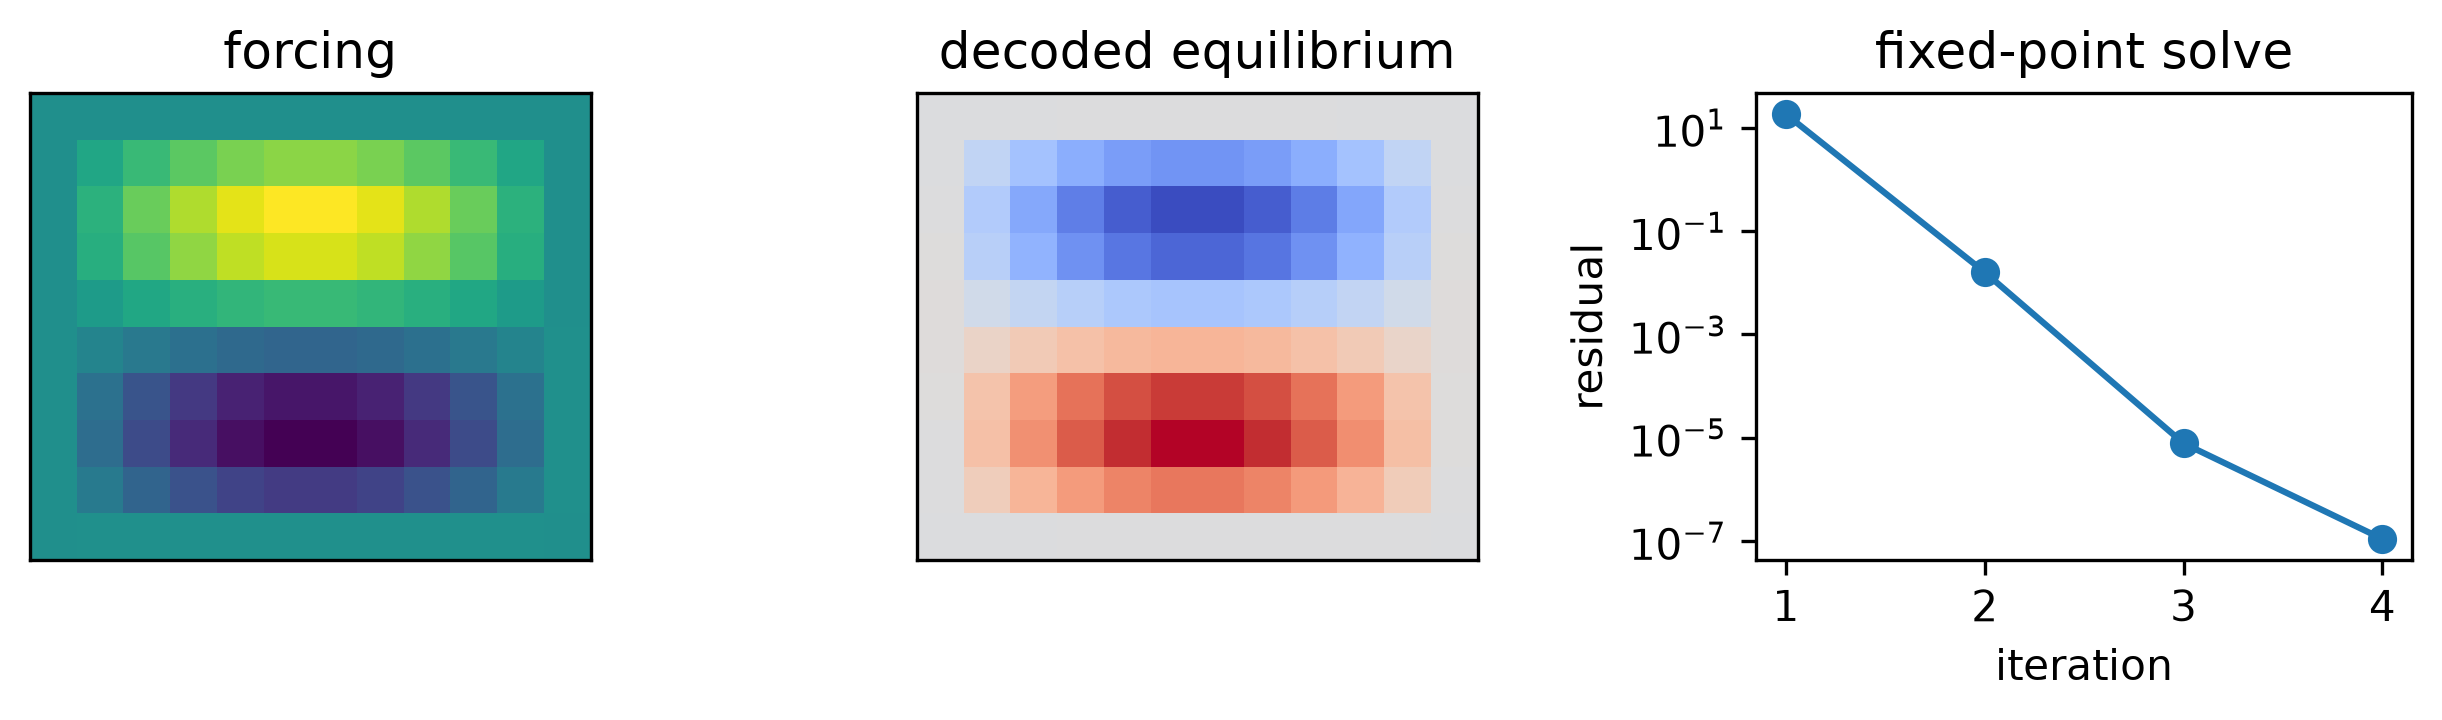

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(8.4, 2.5))
axes[0].imshow(forcing_field[0, 0].detach(), cmap="viridis")
axes[0].set_title("forcing")
axes[1].imshow(fourier_result.output[0, 0].detach(), cmap="coolwarm")
axes[1].set_title("decoded equilibrium")
axes[2].semilogy(
    range(1, len(fourier_result.solver_result.residuals) + 1),
    fourier_result.solver_result.residuals,
    marker="o",
)
axes[2].set_xlabel("iteration")
axes[2].set_ylabel("residual")
axes[2].set_title("fixed-point solve")
for ax in axes[:2]:
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()

In [6]:
larger_field = torch.randn(2, 1, 13, 15, requires_grad=True)
larger_output = fourier_model(larger_field)
larger_output.square().mean().backward()

assert larger_output.shape == (2, 1, 13, 15)
assert larger_field.grad is not None
print("The same parameters ran on a 13 x 15 grid and propagated gradients.")

The same parameters ran on a 13 x 15 grid and propagated gradients.


## 3. Physics-Guided Graph Convection-Diffusion Equilibrium

For node $i$, a convection-diffusion-reaction equation can be discretized as

$$
\begin{aligned}
\dot z_i
&=s_i+r_\theta(z_i) \\
&\quad+\kappa\sum_{j\to i}w_{ji}(z_j-z_i) \\
&\quad-\sum_{j\to i}v_{ji}(z_i-z_j).
\end{aligned}
$$

SILVA names the graph diffusion and directed transport branches separately:

$$
\begin{aligned}
T_\theta(Z;X)
&=\phi\!\left[S_\theta(X)\right. \\
&\qquad+\gamma_rR_\theta(Z) \\
&\qquad+\gamma_dD_\theta(\mathcal L_GZ) \\
&\qquad\left.
-\gamma_aA_\theta(\nabla_VZ)
\right].
\end{aligned}
$$

The fixed point $Z^\star=T_\theta(Z^\star;X)$ is therefore a learned graph
equilibrium with explicit physical branch controls. The construction follows
the physics-guided graph-DEQ direction in [44] without claiming a numerically
identical reproduction of that paper's full experiment.

In [7]:
nodes = torch.linspace(0.0, 1.0, 7)
graph_source = torch.stack([nodes, torch.sin(math.pi * nodes)], dim=-1)
forward_edges = torch.stack([torch.arange(6), torch.arange(1, 7)])
edge_index = torch.cat([forward_edges, forward_edges.flip(0)], dim=1)
edge_weight = torch.linspace(0.5, 1.0, edge_index.shape[1])
edge_velocity = torch.cat([torch.ones(6), -torch.ones(6)])

probe_state = nodes[:, None]
diffusion, directed_gradient = graph_convection_diffusion(
    probe_state,
    edge_index,
    edge_weight=edge_weight,
    edge_velocity=edge_velocity,
)

assert diffusion.shape == directed_gradient.shape == probe_state.shape
print("diffusion range:", float(diffusion.min()), float(diffusion.max()))
print("transport range:", float(directed_gradient.min()), float(directed_gradient.max()))

diffusion range: -0.12121213972568512 0.12878787517547607
transport range: 0.166666641831398 0.1666666865348816


In [8]:
graph_model = SILVAPhysicsGuidedGraphDEQ(
    in_dim=2,
    state_dim=5,
    out_dim=1,
    config=SolverConfig(max_iter=24, tol=1e-6, alpha=0.8),
)
graph_result = graph_model(
    graph_source,
    edge_index,
    edge_weight=edge_weight,
    edge_velocity=edge_velocity,
    return_result=True,
)

assert graph_result.output.shape == (7, 1)
assert graph_result.state.shape == (7, 5)
print("graph residual:", graph_result.solver_result.residual)

graph residual: 3.7578405454041786e-07


### Node Relabeling Check

For a node permutation matrix $\Pi$, graph equivariance requires

$$
\begin{aligned}
\widetilde Z&=\Pi Z,
&\widetilde X&=\Pi X, \\
\widetilde A&=\Pi A\Pi^\top, \\
T(\widetilde Z;\widetilde X,\widetilde A)
&=\Pi T(Z;X,A).
\end{aligned}
$$

The next cell relabels every node and every edge, then maps the prediction back
to the original order.

In [9]:
permutation = torch.tensor([3, 0, 6, 2, 5, 1, 4])
old_to_new = torch.empty_like(permutation)
old_to_new[permutation] = torch.arange(permutation.numel())
relabelled = graph_model(
    graph_source[permutation],
    old_to_new[edge_index],
    edge_weight=edge_weight,
    edge_velocity=edge_velocity,
)

assert torch.allclose(
    relabelled,
    graph_result.output[permutation],
    atol=1e-5,
    rtol=1e-5,
)
print("Node relabeling equivariance verified.")

Node relabeling equivariance verified.


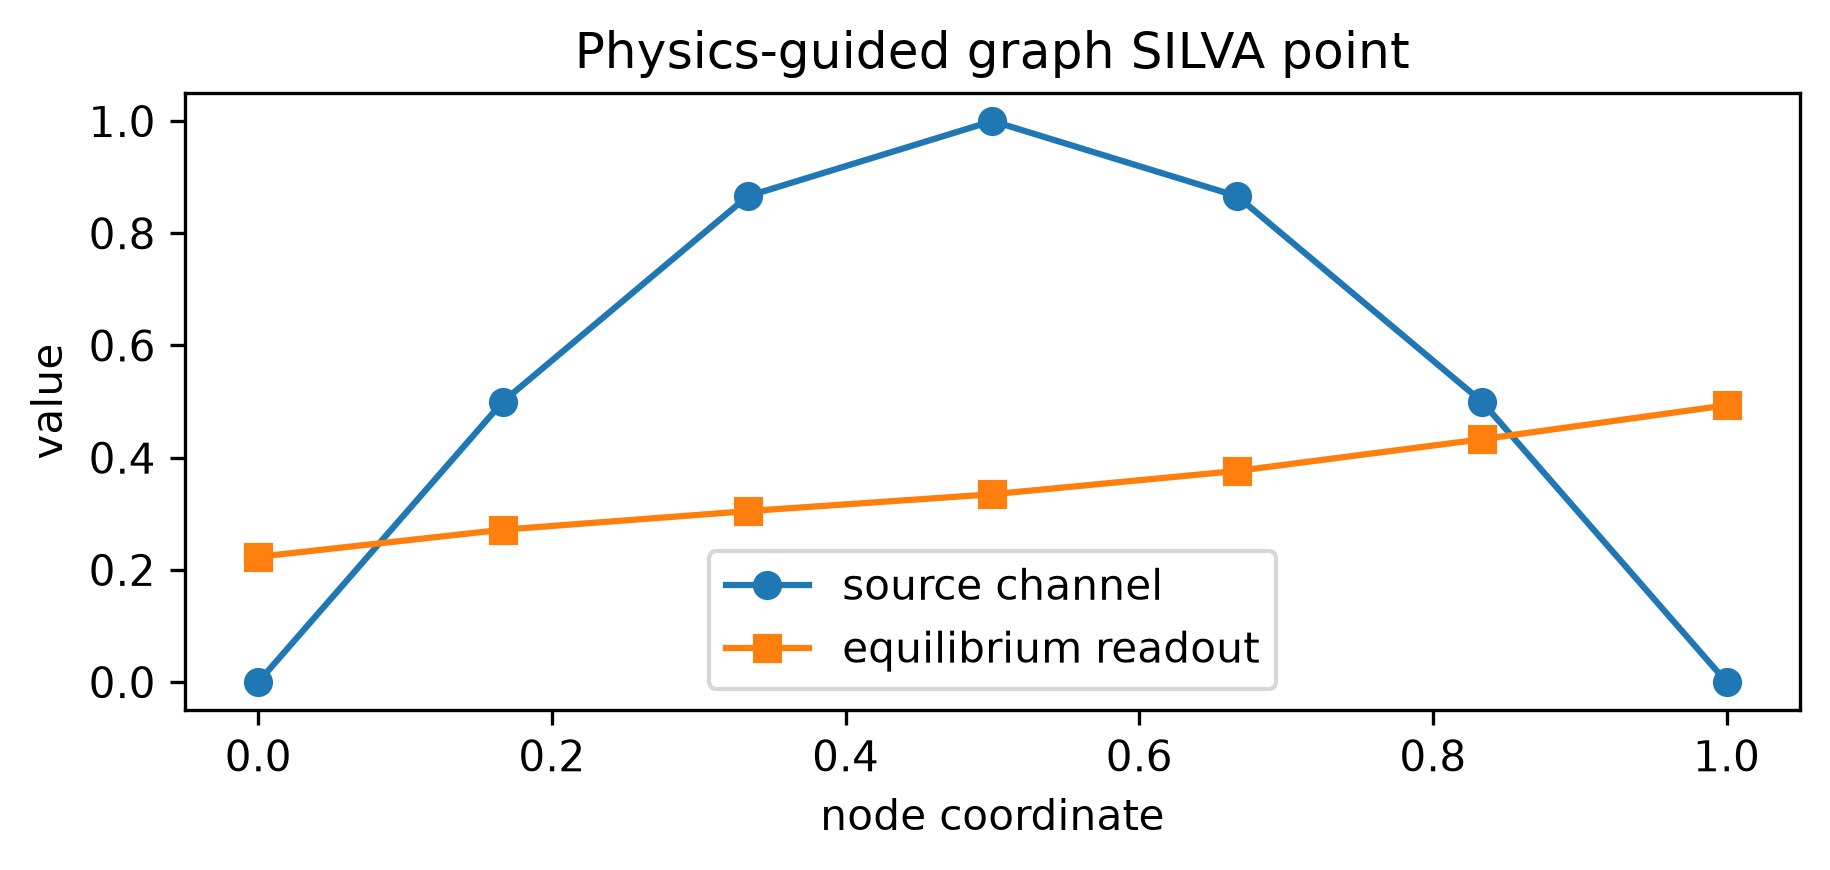

In [10]:
fig, ax = plt.subplots(figsize=(6.2, 3.0))
ax.plot(nodes, graph_source[:, 1], marker="o", label="source channel")
ax.plot(nodes, graph_result.output[:, 0].detach(), marker="s", label="equilibrium readout")
ax.set_xlabel("node coordinate")
ax.set_ylabel("value")
ax.set_title("Physics-guided graph SILVA point")
ax.legend()
fig.tight_layout()

## 4. A Continuous Residual Path to a SILVA Fixed Point

Given any condition-dependent SILVA transition $T_\theta(z;x)$, define

$$
\begin{aligned}
\frac{dz(t)}{dt}&=T_\theta(z(t);x)-z(t), \\
z(0)&=z_0.
\end{aligned}
$$

At a stationary state,

$$
\begin{aligned}
0&=T_\theta(z^\star;x)-z^\star \\
&\Longleftrightarrow
z^\star=T_\theta(z^\star;x).
\end{aligned}
$$

The flow therefore connects a shared initial state to the same equilibrium
condition. SILVA offers Euler and RK4 discretizations and reports the terminal
fixed-point residual. This is a compact residual-flow specialization of the
homotopy connection studied in [46].

In [11]:
class AffineTransition(nn.Module):
    def forward(self, state, condition):
        return 0.5 * state + condition


condition = torch.tensor([[0.4], [-0.7]], dtype=torch.float64)
analytic_fixed_point = 2.0 * condition
homotopy_runs = {}
for integrator in ("euler", "rk4"):
    model = SILVAHomotopyEquilibrium(
        in_dim=1,
        state_dim=1,
        out_dim=1,
        transition=AffineTransition(),
        readout=nn.Identity(),
        steps=64,
        horizon=12.0,
        integrator=integrator,
        learnable_initial=False,
    ).double()
    homotopy_runs[integrator] = model(condition, return_result=True)

for name, result in homotopy_runs.items():
    error = torch.max(torch.abs(result.output - analytic_fixed_point))
    print(name, "error:", float(error), "residual:", result.terminal_residual)
assert torch.allclose(homotopy_runs["rk4"].output, analytic_fixed_point, atol=4e-3)
assert homotopy_runs["rk4"].terminal_residual < homotopy_runs["rk4"].velocity_norms[0]

euler error: 0.0025704034102436157 residual: 0.0012852017051219189
rk4 error: 0.0034702675411930617 residual: 0.0017351337705966419


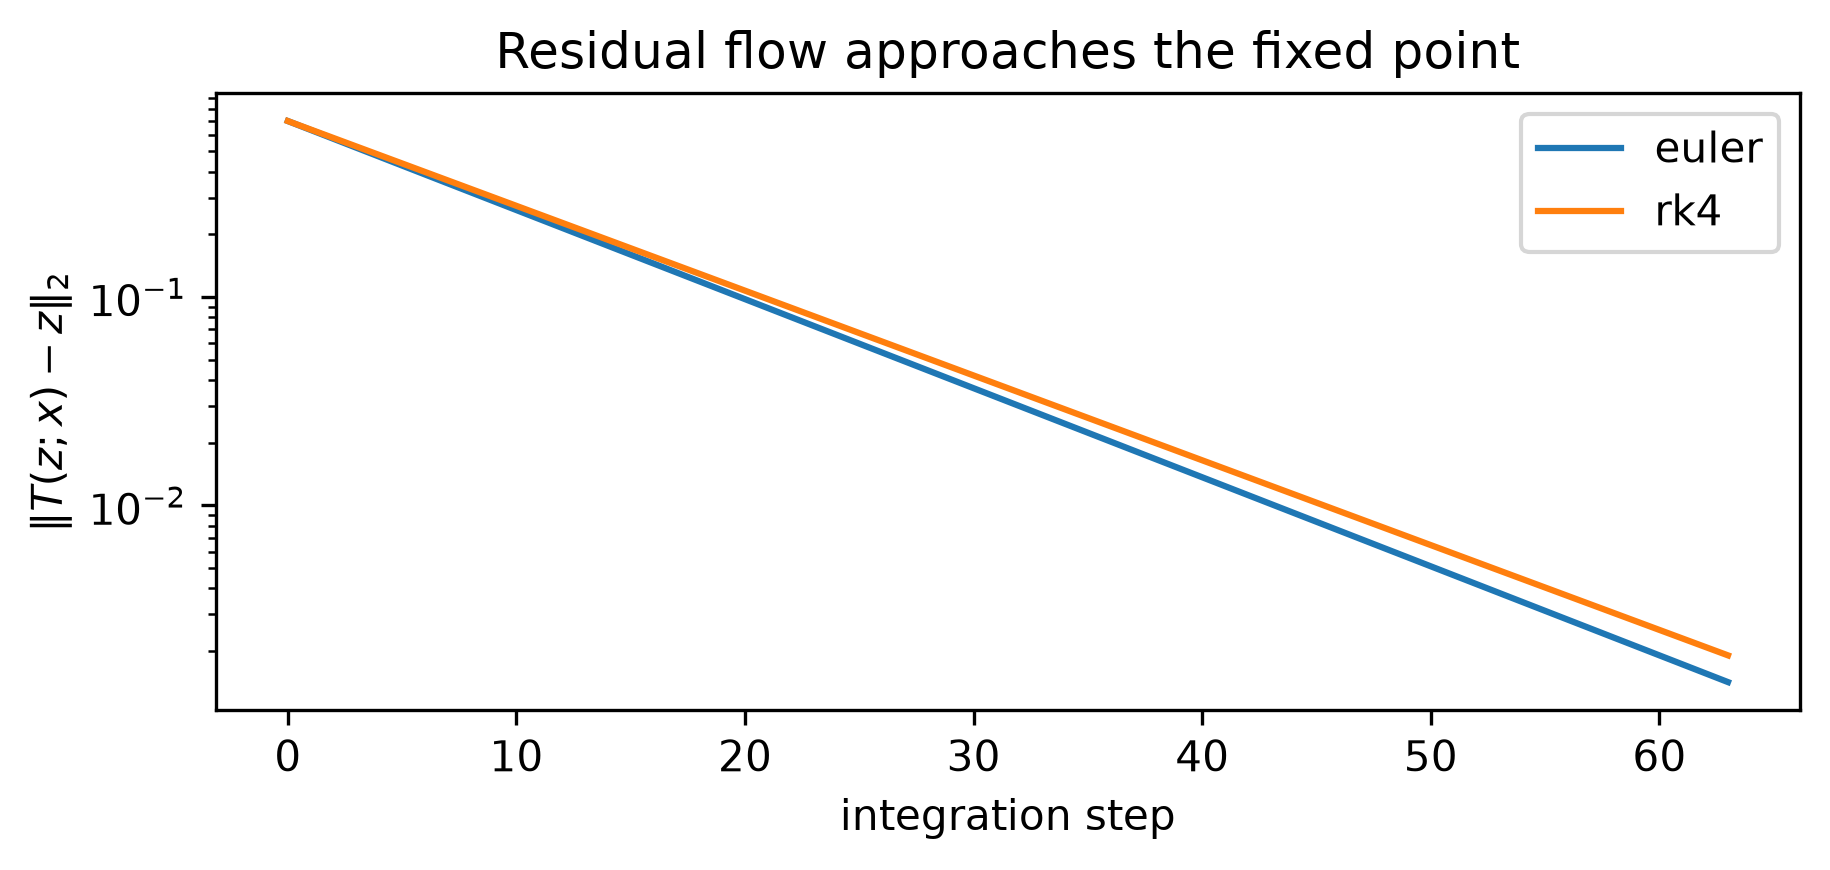

In [12]:
fig, ax = plt.subplots(figsize=(6.2, 3.0))
for name, result in homotopy_runs.items():
    ax.semilogy(range(len(result.velocity_norms)), result.velocity_norms, label=name)
ax.set_xlabel("integration step")
ax.set_ylabel(r"$\|T(z;x)-z\|_2$")
ax.set_title("Residual flow approaches the fixed point")
ax.legend()
fig.tight_layout()

## 5. Distributional SILVA Equilibrium

Now the state is an empirical measure

$$
\mu_Z=\frac{1}{M}\sum_{m=1}^{M}\delta_{z_m},
$$

and the transition $F_\theta(Z,X)$ must be equivariant in the latent ordering
and invariant to the input ordering. SILVA minimizes

$$
\begin{aligned}
G_\theta(Z;X)
&=\frac12D^2\!\left(\right. \\
&\qquad\left.
\mu_Z,\mu_{F_\theta(Z,X)}
\right).
\end{aligned}
$$

with particle updates

$$
Z^{k+1}=Z^k-\eta\nabla_ZG_\theta(Z^k;X).
$$

The discrepancy $D$ can be an energy distance or a Gaussian-kernel MMD. Masks
permit variable particle counts; a fixed mask preserves selected particles.
This follows the distributional equilibrium formulation in [45].

In [13]:
left = torch.tensor([[[0.0], [1.0], [8.0]]])
right = torch.tensor([[[0.2], [1.3], [-9.0]]])
mask = torch.tensor([[True, True, False]])
left_order = torch.tensor([1, 2, 0])
right_order = torch.tensor([2, 0, 1])

reference_mmd = distributional_discrepancy(
    left,
    right,
    kernel="gaussian",
    left_mask=mask,
    right_mask=mask,
)
permuted_mmd = distributional_discrepancy(
    left[:, left_order],
    right[:, right_order],
    kernel="gaussian",
    left_mask=mask[:, left_order],
    right_mask=mask[:, right_order],
)

assert torch.allclose(reference_mmd, permuted_mmd, atol=1e-7)
print("masked MMD:", float(reference_mmd))

masked MMD: 0.03035128116607666


### Equivariant-Invariant Transition Check

If $\pi_Z$ permutes latent particles and $\pi_X$ permutes context particles,
the required property is

$$
F_\theta(\pi_Z Z,\pi_X X)=\pi_ZF_\theta(Z,X).
$$

In [14]:
distribution_transition = SILVADistributionalTransition(2, 4, heads=2).eval()
latent = torch.randn(2, 5, 4)
context = torch.randn(2, 7, 2)
latent_order = torch.tensor([3, 0, 4, 1, 2])
context_order = torch.tensor([6, 2, 0, 5, 1, 4, 3])

reference_transition = distribution_transition(latent, context)
permuted_transition = distribution_transition(
    latent[:, latent_order],
    context[:, context_order],
)

assert torch.allclose(
    permuted_transition,
    reference_transition[:, latent_order],
    atol=1e-5,
    rtol=1e-5,
)
print("Latent equivariance and context invariance verified.")

Latent equivariance and context invariance verified.


In [15]:
particle_context = torch.tensor(
    [[[-1.0, 0.0], [-0.3, 0.5], [0.4, -0.2], [1.0, 0.1]]],
    dtype=torch.float32,
)
distribution_model = SILVADistributionalDEQ(
    input_dim=2,
    latent_dim=4,
    particles=6,
    heads=2,
    kernel="gaussian",
    step_size=0.2,
    max_iter=8,
)
distribution_result = distribution_model(particle_context, return_result=True)

assert distribution_result.state.shape == (1, 6, 4)
assert distribution_result.discrepancies[-1] <= distribution_result.discrepancies[0]
print(
    "discrepancy:",
    distribution_result.discrepancies[0],
    "->",
    distribution_result.discrepancies[-1],
)

discrepancy: 0.5112897157669067 -> 0.44187378883361816


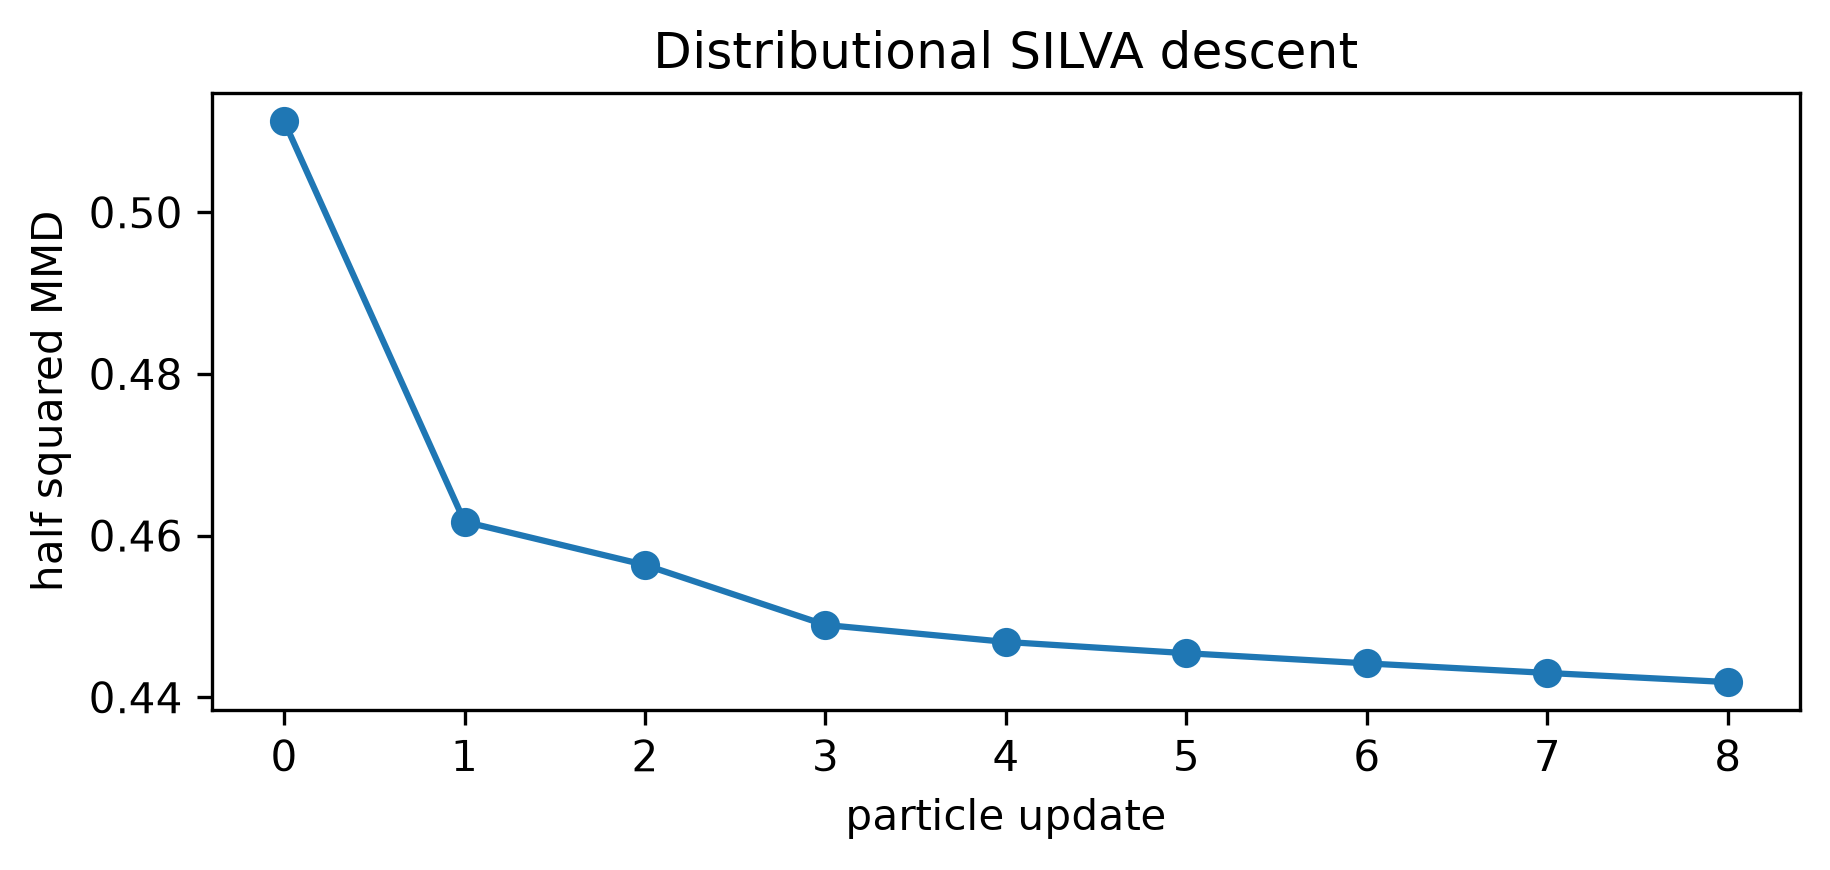

In [16]:
fig, ax = plt.subplots(figsize=(6.2, 3.0))
ax.plot(distribution_result.discrepancies, marker="o")
ax.set_xlabel("particle update")
ax.set_ylabel("half squared MMD")
ax.set_title("Distributional SILVA descent")
fig.tight_layout()

In [17]:
variable_context = torch.randn(2, 5, 2)
context_mask = torch.tensor(
    [[True, True, True, True, True], [True, True, True, False, False]]
)
initial_particles = torch.randn(2, 6, 4)
latent_mask = torch.tensor(
    [[True, True, True, True, True, True], [True, True, True, True, False, False]]
)
fixed_mask = torch.zeros_like(latent_mask)
fixed_mask[:, 0] = True

masked_result = distribution_model(
    variable_context,
    z0=initial_particles,
    context_mask=context_mask,
    latent_mask=latent_mask,
    fixed_mask=fixed_mask,
    return_result=True,
)

assert torch.equal(masked_result.state[:, 0], initial_particles[:, 0])
assert torch.equal(
    masked_result.state.masked_select(~latent_mask.unsqueeze(-1)),
    torch.zeros_like(masked_result.state).masked_select(~latent_mask.unsqueeze(-1)),
)
print("Variable counts and fixed particles verified.")

Variable counts and fixed particles verified.


## 6. Connect All Four Mechanisms

A SILVA architecture may connect heterogeneous points when each edge has an
explicit shape contract. The example below uses:

$$
\begin{aligned}
a
&\xrightarrow{\text{Fourier equilibrium}}u \\
u
&\xrightarrow{\text{field sampling}}X_G \\
X_G
&\xrightarrow{\text{graph equilibrium}}Y_G \\
Y_G
&\xrightarrow{\text{empirical measure}}Z_\mu \\
Z_\mu
&\xrightarrow{\text{residual flow}}y.
\end{aligned}
$$

This is an architectural demonstration, not a claim that this exact pipeline
is appropriate for every scientific task. The important point is that all four
objects remain SILVA points with visible adapters between their state spaces.

In [18]:
field = fourier_result.output.detach()
sampled_values = field[0, 0, ::2, ::3].reshape(-1)
sample_count = sampled_values.numel()
sample_coordinates = torch.linspace(0.0, 1.0, sample_count)
graph_features = torch.stack([sample_coordinates, sampled_values], dim=-1)
ring_source = torch.arange(sample_count)
ring_target = (ring_source + 1) % sample_count
ring_edges = torch.cat(
    [torch.stack([ring_source, ring_target]), torch.stack([ring_target, ring_source])],
    dim=1,
)
ring_velocity = torch.cat([torch.ones(sample_count), -torch.ones(sample_count)])

linked_graph = graph_model(
    graph_features,
    ring_edges,
    edge_velocity=ring_velocity,
)
measure_context = torch.stack([sample_coordinates, linked_graph[:, 0]], dim=-1)[None]
linked_measure = distribution_model(measure_context, return_result=True)

linked_flow = SILVAHomotopyEquilibrium(
    in_dim=4,
    state_dim=4,
    out_dim=1,
    steps=8,
    horizon=4.0,
)
linked_output = linked_flow(linked_measure.state.mean(dim=1))

assert linked_output.shape == (1, 1)
print("field -> graph -> measure -> flow output:", float(linked_output.detach()))

field -> graph -> measure -> flow output: -0.1252797245979309


## 7. Tiny Trained Task

The following fit is intentionally small. It verifies that gradients traverse
the residual-flow discretization and that the transition and readout can be
optimized together. The target $y=2x$ is chosen because the earlier affine
example supplies an analytic reference.

In [19]:
torch.manual_seed(165)
train_x = torch.linspace(-0.5, 0.5, 24)[:, None]
train_y = 2.0 * train_x
trained_flow = SILVAHomotopyEquilibrium(
    in_dim=1,
    state_dim=4,
    out_dim=1,
    steps=6,
    horizon=3.0,
    integrator="rk4",
)
optimizer = torch.optim.Adam(trained_flow.parameters(), lr=0.04)
losses = []
for _ in range(40):
    optimizer.zero_grad()
    loss = torch.mean((trained_flow(train_x) - train_y) ** 2)
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach()))

assert losses[-1] < losses[0]
print("training loss:", losses[0], "->", losses[-1])

training loss: 0.4891417920589447 -> 0.0049957758747041225


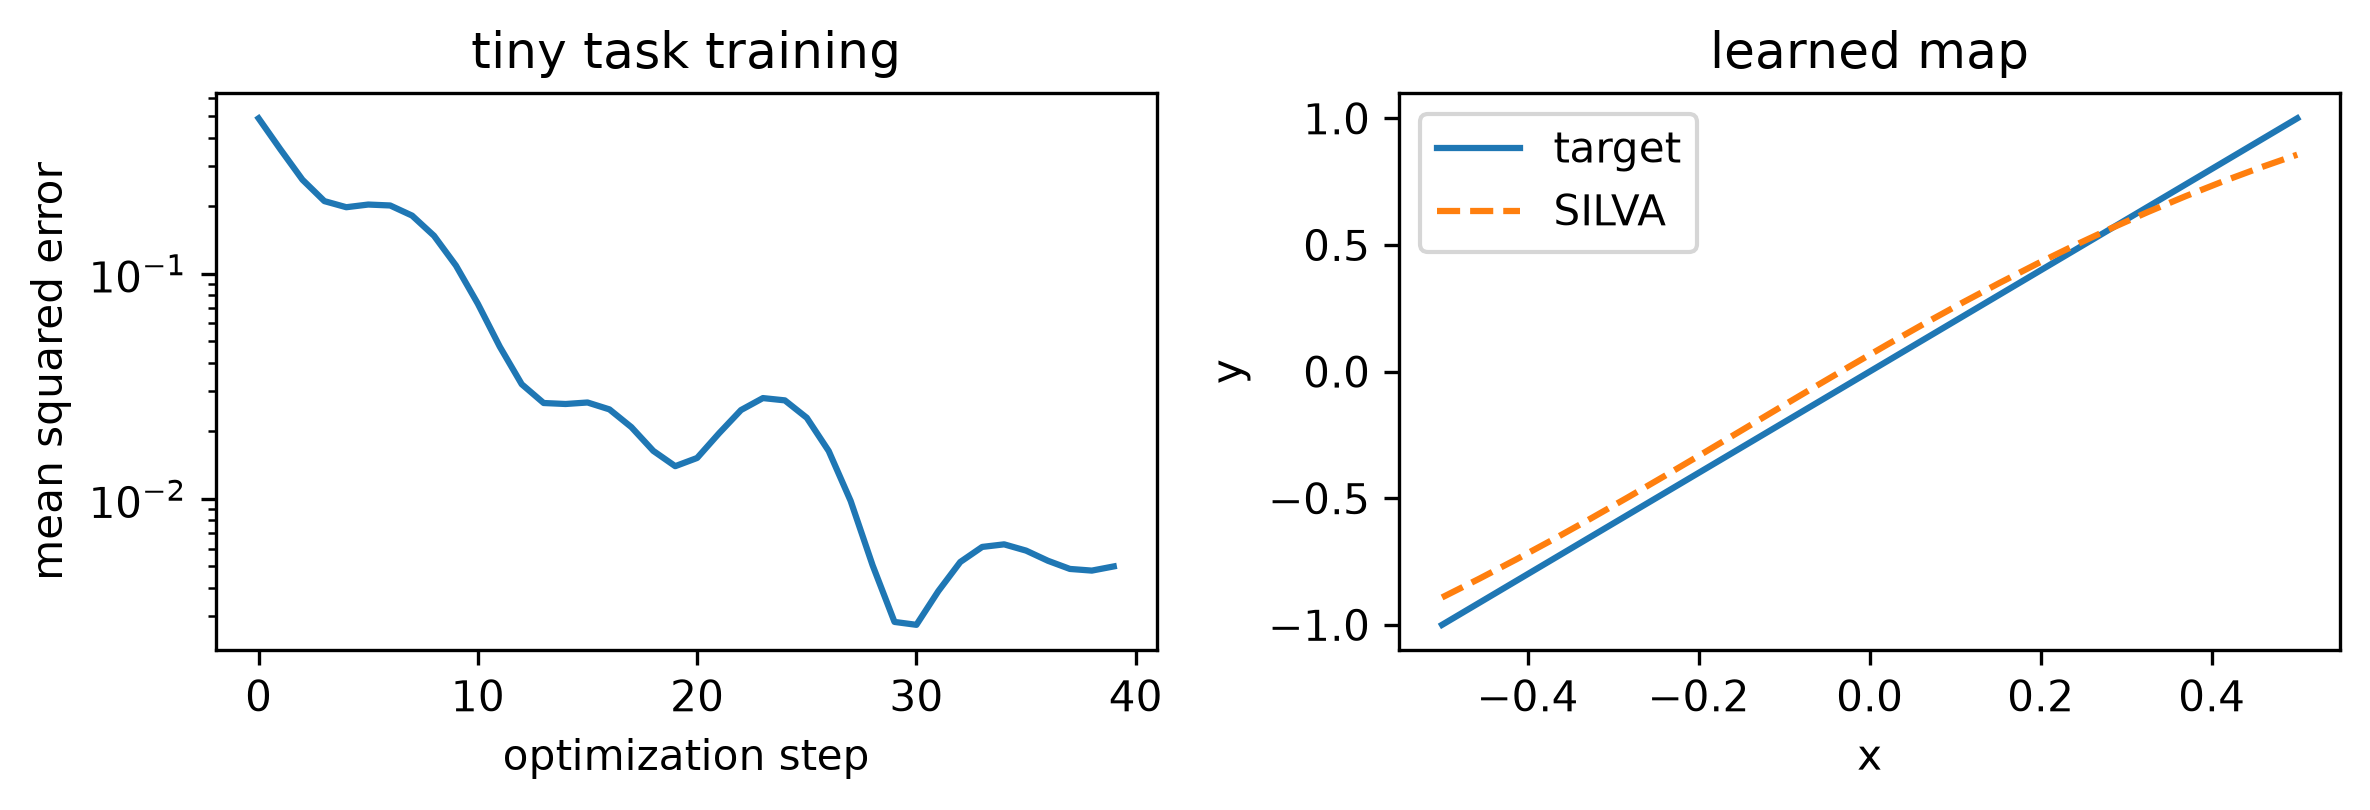

In [20]:
with torch.no_grad():
    trained_prediction = trained_flow(train_x)

fig, axes = plt.subplots(1, 2, figsize=(8.0, 2.8))
axes[0].semilogy(losses)
axes[0].set_xlabel("optimization step")
axes[0].set_ylabel("mean squared error")
axes[0].set_title("tiny task training")
axes[1].plot(train_x[:, 0], train_y[:, 0], label="target")
axes[1].plot(train_x[:, 0], trained_prediction[:, 0], linestyle="--", label="SILVA")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("learned map")
axes[1].legend()
fig.tight_layout()

## 8. Family Registry and Literature Aliases

The canonical names preserve SILVA as the public architecture. Literature
labels resolve to those same classes for discoverability; they do not define a
second implementation hierarchy.

In [21]:
canonical_names = (
    "silva_fno_deq",
    "silva_physics_graph_deq",
    "silva_homotopy_equilibrium",
    "silva_distributional_deq",
)
aliases = ("fno_deq", "pgcn_deq", "homoode", "ddeq")

assert all(name in available_silva_families() for name in canonical_names)
alias_models = (
    silva_equilibrium_model("fno_deq", in_channels=1, state_channels=2, out_channels=1),
    silva_equilibrium_model("pgcn_deq", in_dim=2, state_dim=3, out_dim=1),
    silva_equilibrium_model("homoode", in_dim=1, state_dim=2, out_dim=1),
    silva_equilibrium_model("ddeq", input_dim=2, latent_dim=4),
)
print(dict(zip(aliases, [type(model).__name__ for model in alias_models])))

{'fno_deq': 'SILVAFNODEQ', 'pgcn_deq': 'SILVAPhysicsGuidedGraphDEQ', 'homoode': 'SILVAHomotopyEquilibrium', 'ddeq': 'SILVADistributionalDEQ'}


## 9. Reproduction Boundary

| Result in this notebook | What it establishes |
|---|---|
| forcing reinjection | the input is present at every tied Fourier sublayer |
| two grid resolutions and a backward pass | the field contract is resolution-flexible and differentiable |
| node relabeling | the graph model respects graph indexing |
| affine analytic solution | the residual flow approaches the expected fixed point |
| particle permutations and masks | the distributional transition has the required ordering behavior |
| decreasing discrepancy | the small particle solver moves toward distributional consistency |
| tiny trained task | gradients reach trainable residual-flow components |

These checks reproduce mechanisms at small scale. They do not reproduce the
full benchmark tables of the cited papers. Larger benchmark claims require the
published datasets, preprocessing, budgets, metrics, and repeated trials.

## 10. Related Families and Deliberate Boundaries

- Multiscale DEQ, IGNN, and MIGNN-style propagation fit existing SILVA
  multiscale and graph abstractions [5, 36, 47].
- DeqIR's coupled restoration trajectory is represented by SILVA's joint
  trajectory equilibrium mechanism [49].
- GET-style generation distillation [48] needs a task-specific image training
  protocol before it can be presented as a validated SILVA family.
- DEQ-MD [50] needs a positive-domain mirror map and explicit operator-splitting
  contracts; those are documented as extension requirements, not silently
  approximated by Euclidean descent.

This boundary keeps the implementation claims exact while leaving the general
SILVA decomposition open to further internal mappings.

## From 16 Frontier Equilibrium Families to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the tensor solved to equilibrium |
| Condition | the observed input or source tensor |
| Repeated computation | the state-preserving transition evaluated by the root solver |
| Required invariants | shape, device, dtype, finiteness, and differentiability |
| Replaceable components | initializer, source encoder, transition, readout, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


In [22]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**fixed-point residual and task error against a deterministic target**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **state width, batch size, and data volume**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [23]:
notebook_reproduction_record = {
    "notebook": '16_frontier_equilibrium_families.ipynb',
    "state": 'the tensor solved to equilibrium',
    "condition": 'the observed input or source tensor',
    "transition": 'the state-preserving transition evaluated by the root solver',
    "invariants": 'shape, device, dtype, finiteness, and differentiability',
    "compact_metric": 'fixed-point residual and task error against a deterministic target',
    "scale_axis": 'state width, batch size, and data volume',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '16_frontier_equilibrium_families.ipynb',
 'state': 'the tensor solved to equilibrium',
 'condition': 'the observed input or source tensor',
 'transition': 'the state-preserving transition evaluated by the root solver',
 'invariants': 'shape, device, dtype, finiteness, and differentiability',
 'compact_metric': 'fixed-point residual and task error against a deterministic target',
 'scale_axis': 'state width, batch size, and data volume'}

## Where to Go Next

| Question | Page |
| --- | --- |
| How is each recent mechanism derived inside SILVA? | [Recent Equilibrium Families](https://jseluis.github.io/silva-networks/learn/frontier-equilibrium-families/) |
| Where do the four compact cases run? | [Recent Equilibrium Example](https://jseluis.github.io/silva-networks/examples/frontier-equilibria/) |
| Which constructors and diagnostics are public? | [Recent Equilibrium API](https://jseluis.github.io/silva-networks/api/frontier/) |
